[1] "coefficients"    "scores"          "loadings"        "loading.weights"
 [5] "Yscores"         "Yloadings"       "projection"      "Xmeans"         
 [9] "Ymeans"          "fitted.values"   "residuals"       "Xvar"           
[13] "Xtotvar"         "fit.time"        "ncomp"           "method"         
[17] "validation"      "call"            "terms"           "model"

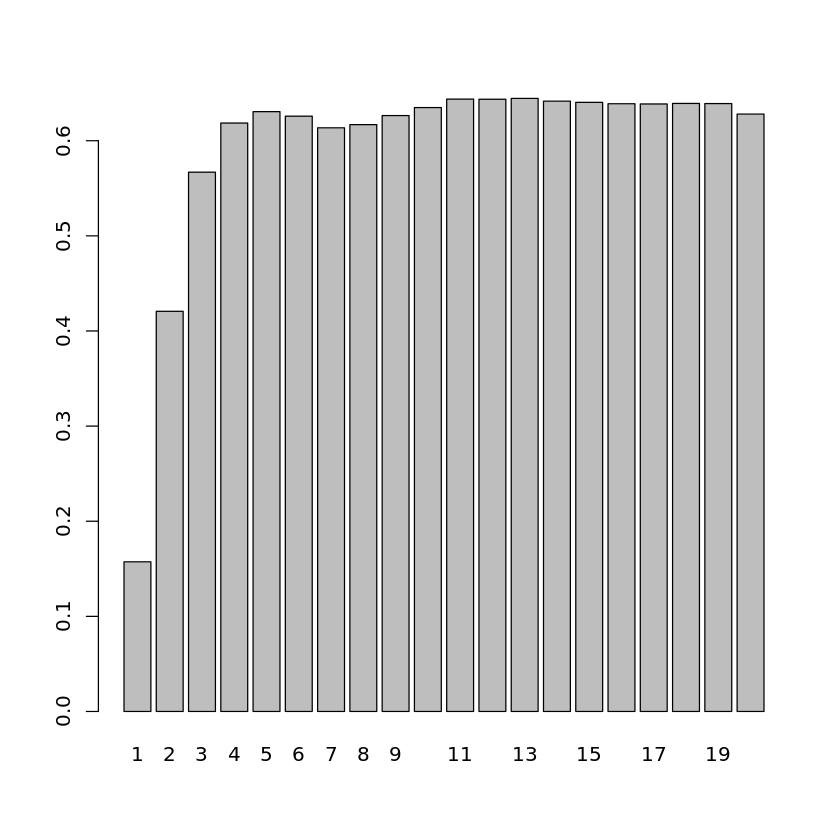

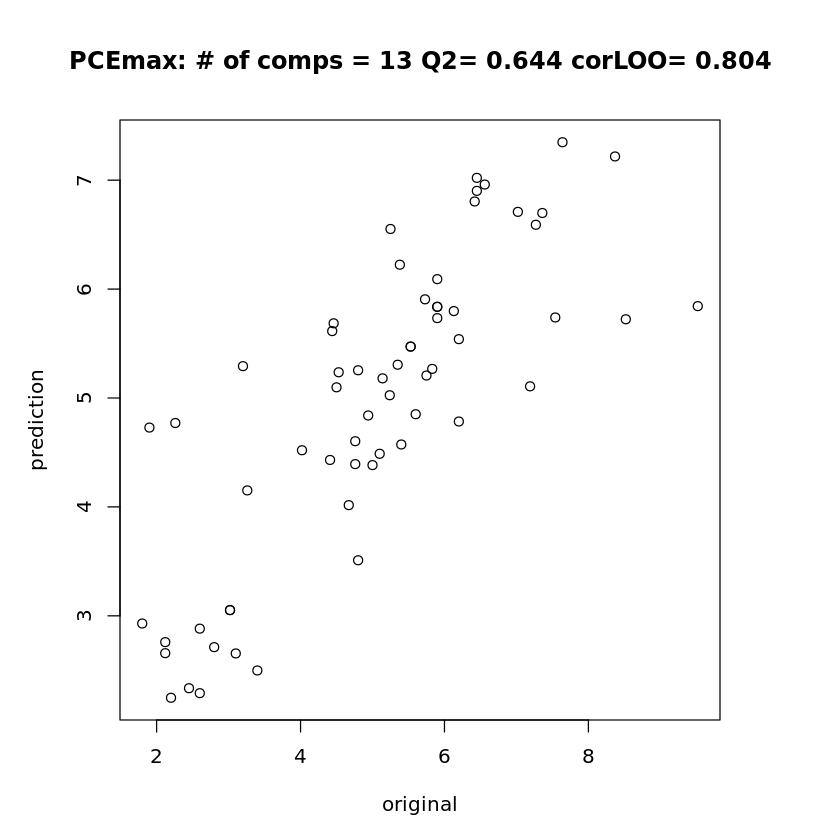

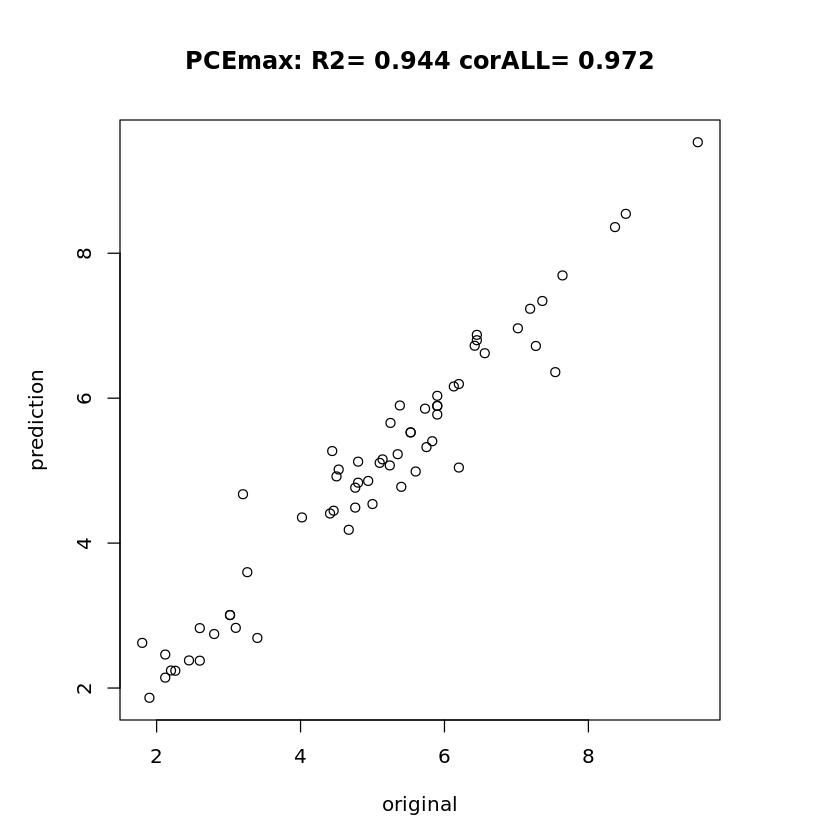

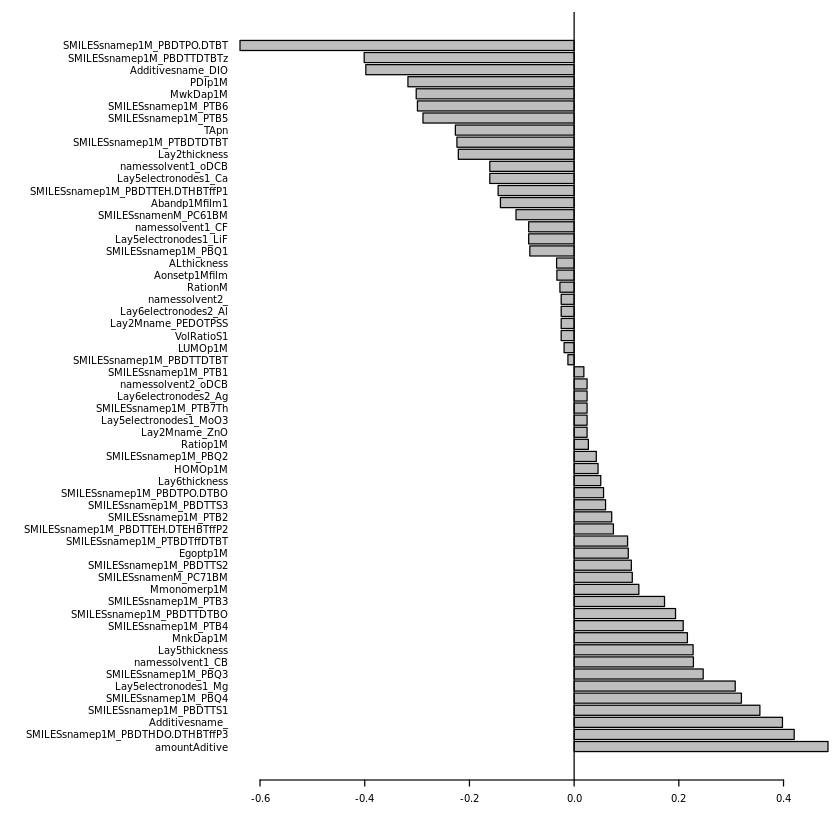

In [2]:
if(!require(pls)){
  install.packages("pls");library(pls)
}
if(!require(plsVarSel)){
  install.packages("plsVarSel");library(plsVarSel)
}
#[1]
ifname <- "DataMerge20211213.csv"
readData <- read.delim(ifname, header=T,sep=",",row.names=1,as.is=TRUE,strip.white=FALSE)
nf1<-dim(readData)[2]
charaCheck<-rep(FALSE,nf1)
for(i in 1:nf1){
  charaCheck[i]<-!is.character(readData[,i])
}
readData2<-readData[,charaCheck]
#[2]
yname<-"PCEmax"     #"Jsc","Voc","FF","PCEmax"
Y<-readData2[,yname]
rmlist<-c("Jsc","Voc","FF","PCEmax","PCEcal", "PCEdiff", "PCEave")
collist<-colnames(readData2)
Xnames<-setdiff(collist, rmlist)
X<-readData2[,c(Xnames)]
dMerge<-data.frame(Y,X)
Nadata<-na.omit(dMerge)
#[3]
sdcheck<-apply(Nadata,2,sd)
TF<-(sdcheck!=0)
ssd<-scale(Nadata[,TF])
ssd[,1]<-Nadata[,1]
#[4]
YXdata<-data.frame(ssd)
#----------------------------------------------------------------
result1.pls<-plsr(Y~.,data=YXdata,scale=FALSE,validation="LOO")
names(result1.pls)
plspress<-result1.pls$validation$PRESS
ncomponent<-which.min(plspress)
#---[sum((dataUsed$Y-Ypred1)^2) == plspress]--------------------
Ypred1<-result1.pls$validation$pred[,,ncomponent]
#[5]--- Q2
tss<-sum((YXdata[,1]-mean(YXdata[,1]))^2)
Q2<-1-plspress/tss
mc<-which.max(Q2)
par(cex=1.0)
barplot(Q2[1:20],names.arg=1:20)
corLOO<-cor(YXdata[,1],Ypred1)
titleR<-paste0(yname,": # of comps = ",mc, " Q2= ",substring(max(Q2),1,5),
               " corLOO= ",substring(corLOO,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred1,xlab="original", ylab="prediction",main=titleR)
#[6]------------------------------------------
Ypred2<-predict(result1.pls,newdata=YXdata, ncomp = ncomponent)
rss<-sum((YXdata[,1]-Ypred2)^2)
R2<-1-rss/tss
CR<-cor(YXdata[,1],Ypred2)
titleR<-paste0(yname,": R2= ",substring(R2,1,5)," corALL= ",substring(CR,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred2,xlab="original",ylab="prediction",main=titleR)
#[7]---------------------------------------
par(cex=0.5)
par(mar=c(5,20,1,1))
corR<-sort(coefficients(result1.pls,ncomp=ncomponent)[,1,1],decreasing=TRUE)
barplot(corR,horiz=TRUE,las=1)
abline(v=0,lty=1)